In [1]:
import matplotlib.pyplot as plt
import numpy as np

## Spectre du noyau exponentiel et de ses approximations

Nous nous intéressons au noyau softmax (exponentiel) :
$$\forall x, y \in \mathbb{R}^d, \quad \text{SM}(x, y) = \exp(x^\top y)$$

### Définition du spectre d'un noyau

Soit $\mu$ une mesure de probabilité sur $\mathbb{R}^d$ et $L_2(\mu)$ l'espace des fonctions 
de carré intégrable par rapport à $\mu$. On définit l'opérateur intégral $T_k$ : pour tout 
$f \in L_2(\mu)$ et $x \in \mathbb{R}^d$,

$$T_k f(x) = \int_{\mathbb{R}^d} k(x, y) f(y) \, d\mu(y)$$

Le **spectre** de $k$ est l'ensemble des valeurs propres $(\lambda_m)_{m \geq 0}$ de $T_k$,
c'est-à-dire les réels tels qu'il existe $\phi_m \in L_2(\mu)$ non nul vérifiant :

$$T_k \phi_m = \lambda_m \phi_m$$


Définissons les fonctions avec lesquelles nous allons travailler (Noyau exponnentiel, noyau gaussien, approximations du noyau exponnentiel)

In [2]:
def sm_with_norm(x, y):
    """Noyau softmax exact : exp(x^T y / sqrt(d))"""
    d = len(x)
    return np.exp(x @ y / np.sqrt(d))

In [3]:
def sm(x, y):
    """Noyau softmax exact : exp(x^T y)"""
    return np.exp(x @ y )

Feature map trigonométrique : 
$$\phi^{\text{trig}}(x) = \frac{e^{\|x\|^2/2}}{\sqrt{D}} 
\begin{bmatrix} \cos(\omega_1^\top x) \\ \sin(\omega_1^\top x) \\ \vdots \\ 
\cos(\omega_D^\top x) \\ \sin(\omega_D^\top x) \end{bmatrix} \in \mathbb{R}^{2D}$$

In [4]:
def phi_trig(x, omegas):
    """
    Feature map trigonométrique pour SM.
    omegas : (D, d) — vecteurs aléatoires gaussiens
    Retourne vecteur de taille 2D.
    """
    D = omegas.shape[0]
    projections = omegas @ x          # (D,)
    scale = np.exp(np.linalg.norm(x)**2 / 2) / np.sqrt(D)
    return scale * np.concatenate([np.cos(projections), 
                                   np.sin(projections)])

Feature map SM+ :
$$\phi^{+}(x) = \frac{e^{-\|x\|^2/2}}{\sqrt{D}} 
\begin{bmatrix} \exp(\omega_1^\top x) \\ \vdots \\ \exp(\omega_D^\top x) 
\end{bmatrix} \in \mathbb{R}^{D}$$

In [5]:
def phi_pos(x, omegas):
    """
    Feature map positive (PRF) pour SM.
    omegas : (D, d)
    Retourne vecteur de taille D.
    """
    D = omegas.shape[0]
    projections = omegas @ x          # (D,)
    scale = np.exp(-np.linalg.norm(x)**2 / 2) / np.sqrt(D)
    return scale * np.exp(projections)

Feature map SMhyp :
$$\phi^{\text{hyp}+}(x) = \frac{e^{-\|x\|^2/2}}{\sqrt{2D}} 
\begin{bmatrix} \exp(\omega_1^\top x) \\ \exp(-\omega_1^\top x) \\ \vdots \end{bmatrix} $$


In [6]:
def phi_hyp(x, omegas):
    """
    Feature map hyperbolique (variance réduite) pour SM.
    omegas : (D, d)
    Retourne vecteur de taille 2D.
    """
    D = omegas.shape[0]
    projections = omegas @ x         
    scale = np.exp(-np.linalg.norm(x)**2 / 2) / np.sqrt(2 * D)
    return scale * np.concatenate([np.exp(projections), 
                                   np.exp(-projections)])

In [7]:
# --- Approximations du kernel (à partir des feature maps) ---

def sm_trig(x, y, omegas):
    return phi_trig(x, omegas) @ phi_trig(y, omegas)

def sm_pos(x, y, omegas):
    return phi_pos(x, omegas) @ phi_pos(y, omegas)

def sm_hyp(x, y, omegas):
    return phi_hyp(x, omegas) @ phi_hyp(y, omegas)

### Opérateur de covariance et matrice aléatoire 

Pour calculer les valeurs propres d'un noyau $k$ symétrique défini positif de $\mathbb{R}^d \times \mathbb{R}^d \to \mathbb{R}$, nous nous intéressons à l'opérateur covariance et la matrice associé à K. 

Soit $\phi : \mathbb{R}^d \to H$ avec H un hilbert tel que pour tout $(x,y) \in \mathbb{R}^d$, $k(x,y) = \langle \phi(x), \phi(y) \rangle$. L'opérateur de covariance $\Sigma : H \to H$ est tel que pour tout $f,g \in H$,
$$ \langle f, \Sigma g \rangle =  \int_{\mathbb{R}^d} \langle f, \phi(x) \rangle \langle g, \phi(x) \rangle d\mu(x)  $$

i.e  $$\Sigma g  = \int_{\mathbb{R}^d} \phi(x)  \langle g, \phi(x) \rangle d\mu(x)  $$

Soit  $n$ observations $x_1, \dots, x_n$ i.i.d. suivant $\mu$. La matrice associée au kernel k s'écrit $K \in \mathbb{R}^{n \times n}$ avec $K_{ij} = k(x_i, x_j)$.

L'opérateur de covariance et l'opérateur intégrale possedent les mêmes valeurs propres, i.e le spectre de k. De plus, les valeurs propres de 
$\frac{1}{n}K$ convergent vers les $\lambda_m$ quand $n \to \infty$.


Calculon des valeurs approchées du spectre du noyau exponnetiel : 

In [8]:
# Construction de la matrice du noyau
def kernel_matrix(X, kernel_fn, omegas=None):
    """Matrice de noyau entre les ensembles X et Y."""
    n = len(X)
    K = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            if omegas is not None:
                K[i, j] = kernel_fn(X[i], X[j], omegas)
            else:
                K[i, j] = kernel_fn(X[i], X[j])
    return K

# Calcul du spectre de la matrice du noyau
def kernel_spectrum(X, kernel_fn, omegas=None):
    K = kernel_matrix(X, kernel_fn, omegas)/len(X)  
    eigenvalues = np.linalg.eigvals(K)
    return np.sort(eigenvalues)[::-1]  # Tri décroissant


In [22]:
D = 100 # dimension de la feature map
n = 100 # nombre de échantillons
d = 10 

On remarque qu'on obtient différents resultats selon les différentes méthodes de normalisation:

Sans normalisation : noyau exponentiel classique et données non normalisées

In [23]:
# Spectre des approximations du noyau exponentiel 
omegas = np.random.randn(D, d) # Vecteurs aléatoires pour les feature maps
X = np.random.randn(n,d)
K_trig = kernel_spectrum(X, sm_trig, omegas)
K_pos = kernel_spectrum(X, sm_pos, omegas)
K_hyp = kernel_spectrum(X, sm_hyp, omegas)
K_exp = kernel_spectrum(X, sm) # Spectre du noyau exact

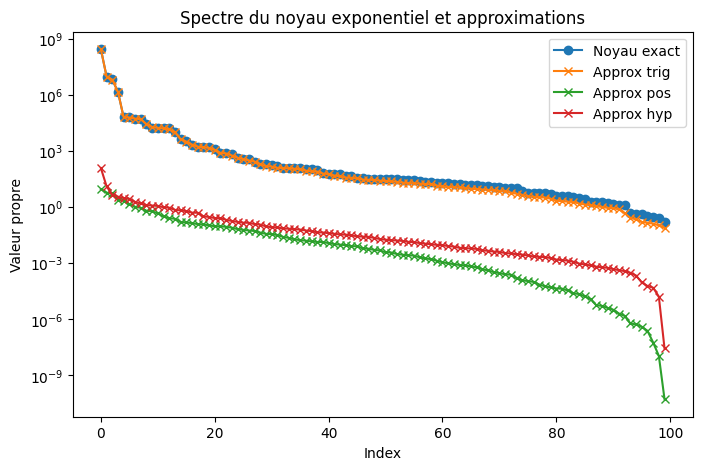

In [24]:
# Plot du spectre des approximations et du noyau exact sans normalisation
plt.figure(figsize=(8, 5))
plt.plot(K_exp, label='Noyau exact', marker='o')   
plt.plot(K_trig, label='Approx trig', marker='x')
plt.plot(K_pos, label='Approx pos', marker='x')
plt.plot(K_hyp, label='Approx hyp', marker='x')
plt.yscale('log')
plt.title('Spectre du noyau exponentiel et approximations')
plt.xlabel('Index')
plt.ylabel('Valeur propre')
plt.legend()


Noyau exponentiel normalisé et données non normalisées

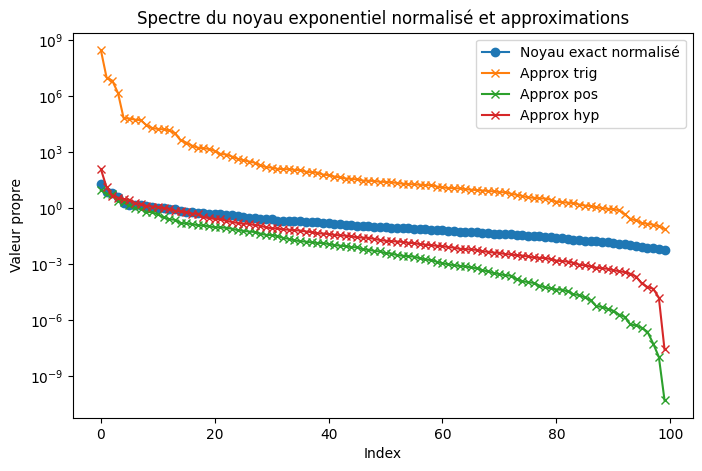

In [25]:
# plot du spectre des approximations et du noyau exact avec normalisation
K_exp_norm = kernel_spectrum(X, sm_with_norm)
plt.figure(figsize=(8, 5))
plt.plot(K_exp_norm, label='Noyau exact normalisé', marker='o')
plt.plot(K_trig, label='Approx trig', marker='x')
plt.plot(K_pos, label='Approx pos', marker='x')
plt.plot(K_hyp, label='Approx hyp', marker='x')
plt.yscale('log')
plt.title('Spectre du noyau exponentiel normalisé et approximations')
plt.xlabel('Index')
plt.ylabel('Valeur propre')
plt.legend()
plt.show()

Noyau exponentiel classique et données normalisés par $\sqrt{d}$

In [ ]:
# Spectre des approximations du noyau exponentiel 
omegas = np.random.randn(D, d) # Vecteurs aléatoires pour les feature maps
X_norm_carre = np.random.randn(n,d)*(d)**(-0.5)
K_trig_carre = kernel_spectrum(X_norm_carre, sm_trig, omegas)
K_pos_carre = kernel_spectrum(X_norm_carre, sm_pos, omegas)
K_hyp_carre = kernel_spectrum(X_norm_carre, sm_hyp, omegas)
K_exp_carre = kernel_spectrum(X_norm_carre, sm) # Spectre du noyau exact

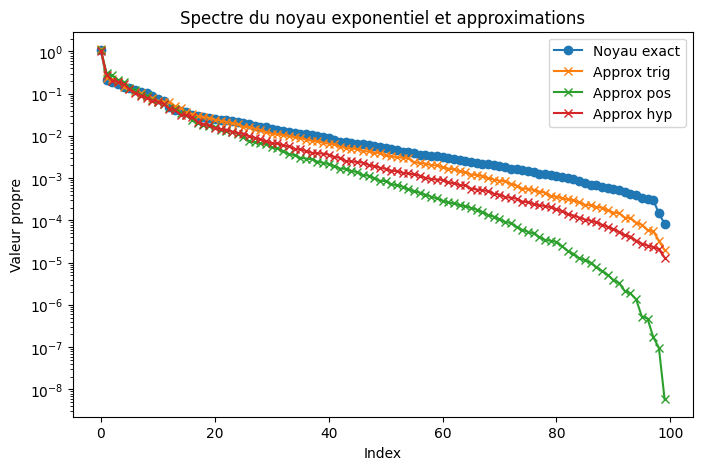

In [ ]:
# Plot du spectre des approximations et du noyau exact sans normalisation
plt.figure(figsize=(8, 5))
plt.plot(K_exp_carre, label='Noyau exact', marker='o')   
plt.plot(K_trig_carre, label='Approx trig', marker='x')
plt.plot(K_pos_carre, label='Approx pos', marker='x')
plt.plot(K_hyp_carre, label='Approx hyp', marker='x')
plt.yscale('log')
plt.title('Spectre du noyau exponentiel et approximations')
plt.xlabel('Index')
plt.ylabel('Valeur propre')
plt.legend()

Noyau exponentiel classique et données normalisés par $d^{\frac{1}{4}}$

In [32]:
# Spectre des approximations du noyau exponentiel 
# avec n = 100 (nombre de échantillons) et D = 1000 (dimension de la feature map)
omegas = np.random.randn(D, d) # Vecteurs aléatoires pour les feature maps
X_norm_quatrieme = np.random.randn(n,d)*(d)**(-0.25)
K_trig_quatrieme = kernel_spectrum(X_norm_quatrieme, sm_trig, omegas)
K_pos_quatrieme = kernel_spectrum(X_norm_quatrieme, sm_pos, omegas)
K_hyp_quatrieme = kernel_spectrum(X_norm_quatrieme, sm_hyp, omegas)
K_exp_quatrieme = kernel_spectrum(X_norm_quatrieme, sm) # Spectre du noyau exact

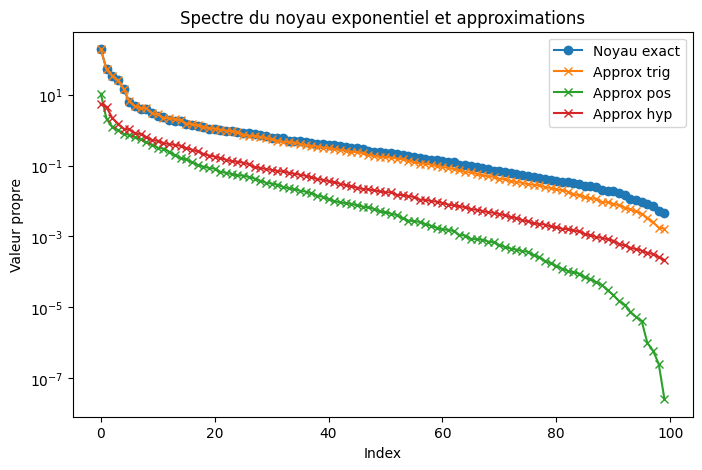

In [ ]:
# Plot du spectre des approximations et du noyau exact sans normalisation
plt.figure(figsize=(8, 5))
plt.plot(K_exp_quatrieme, label='Noyau exact', marker='o')   
plt.plot(K_trig_quatrieme, label='Approx trig', marker='x')
plt.plot(K_pos_quatrieme, label='Approx pos', marker='x')
plt.plot(K_hyp_quatrieme, label='Approx hyp', marker='x')
plt.yscale('log')
plt.title('Spectre du noyau exponentiel et approximations')
plt.xlabel('Index')
plt.ylabel('Valeur propre')
plt.legend()

Observons également l'écart-type - non normalisée: 

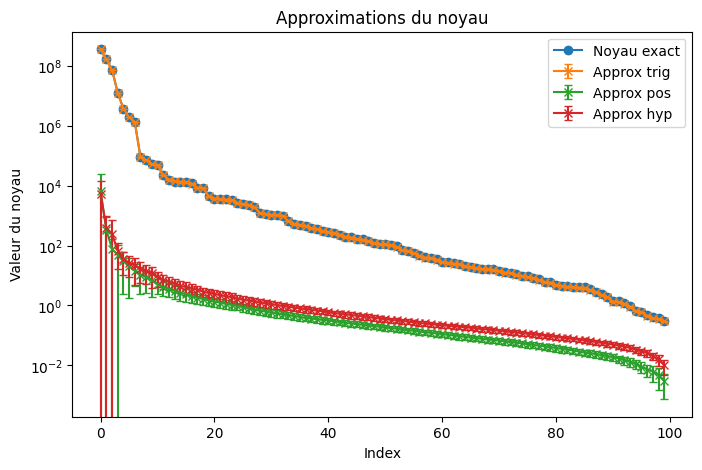

In [17]:
# Paramètres
D = 1000
n_trials = 20  # nombre de tirages d'omegas

# Calcul des spectres pour plusieurs tirages d'omegas
spectra_trig = []
spectra_pos  = []
spectra_hyp  = []

for _ in range(n_trials):
    omegas = np.random.randn(D, d)
    spectra_trig.append(kernel_spectrum(X, sm_trig, omegas))
    spectra_pos.append(kernel_spectrum(X, sm_pos,   omegas))
    spectra_hyp.append(kernel_spectrum(X, sm_hyp,   omegas))

# Conversion en arrays (n_trials, n)
spectra_trig = np.array(spectra_trig)
spectra_pos  = np.array(spectra_pos)
spectra_hyp  = np.array(spectra_hyp)

# Moyenne et écart-type sur les tirages d'omegas
mean_trig, std_trig = spectra_trig.mean(axis=0), spectra_trig.std(axis=0)
mean_pos,  std_pos  = spectra_pos.mean(axis=0),  spectra_pos.std(axis=0)
mean_hyp,  std_hyp  = spectra_hyp.mean(axis=0),  spectra_hyp.std(axis=0)

# Plot avec barres d'erreur
plt.figure(figsize=(8, 5))
plt.plot(K_exp, label='Noyau exact', marker='o')
plt.errorbar(range(len(mean_trig)), mean_trig, yerr=std_trig, label='Approx trig', marker='x', capsize=3)
plt.errorbar(range(len(mean_pos)),  mean_pos,  yerr=std_pos,  label='Approx pos', marker='x', capsize=3)
plt.errorbar(range(len(mean_hyp)),  mean_hyp,  yerr=std_hyp,  label='Approx hyp', marker='x', capsize=3)
plt.yscale('log')
plt.xlabel('Index')
plt.ylabel('Valeur du noyau')
plt.title('Approximations du noyau')
plt.legend()
plt.show()

Pour vérifier le resultat, on compare les valeurs propres calculés avec les valeurs propres de la matrice de gram associée G définie par le produit scalaire entre les features maps : 
$$G_{ij} = \langle \phi_i, \phi_j \rangle_{L_2(\mu)} = \int \phi_i(x)\phi_j(x) \, d\mu(x)$$

Calculons les différentes matrice de Gram pour chaque feature map :

1. Feature map trigonometrique

$$\phi^{\text{trig}}(x) = \frac{e^{\|x\|^2/2}}{\sqrt{D}} 
\begin{bmatrix} \cos(\omega_1^\top x) \\ \sin(\omega_1^\top x) \\ \vdots \\ 
\cos(\omega_D^\top x) \\ \sin(\omega_D^\top x) \end{bmatrix} \in \mathbb{R}^{2D}$$

$$G_{ij} = \frac{1}{D} \int_{\mathbb{R}^d} \frac{e^{-\|x\|^2 / 2}}{(2\pi)^{d/2}} e^{\|x\|^2}
( \cos{\omega_i^\top x}\cos{\omega_j^\top x} + \cos{\omega_i^\top x}\sin{\omega_j^\top x}
+ \sin{\omega_i^\top x}\cos{\omega_j^\top x} + \sin{\omega_i^\top x}\sin{\omega_j^\top x} ) dx$$





2. Feature map positif 

 $\phi^+_i(x) = \frac{e^{-\|x\|^2 /2}}{\sqrt{D}} e^{\omega_i^\top x}$, donc :

$$G_{ij} = \frac{1}{D} \int_{\mathbb{R}^d} e^{-\|x\|^2} e^{(\omega_i + \omega_j)^\top x} \cdot \frac{e^{-\|x\|^2/2}}{(2\pi)^{d/2}} \, dx 
= \frac{1}{D} \int_{\mathbb{R}^d} \frac{1}{(2\pi)^{d/2}} e^{-\frac{3}{2}\|x\|^2 + (\omega_i+\omega_j)^\top x} \, dx$$

Or :

$$-\frac{3}{2}\|x\|^2 + (\omega_i+\omega_j)^\top x 
= -\frac{3}{2}\left\|x - \frac{\omega_i+\omega_j}{3}\right\|^2 + \frac{\|\omega_i+\omega_j\|^2}{6}$$

En intégrant la gaussienne $\mathcal{N}\!\left(\frac{\omega_i+\omega_j}{3},\, \frac{1}{3}I_d\right)$, on obtient :

$$\boxed{G_{ij} = \frac{1}{D \cdot 3^{d/2}} \exp\!\left(\frac{\|\omega_i + \omega_j\|^2}{6}\right)}$$


In [18]:
def gram_exact_pos(omegas, d):
    """
    Matrice de Gram analytique pour phi_pos et mu = N(0, I_d).
    """
    D = omegas.shape[0]
    
    # ||omega_i + omega_j||^2 = ||omega_i||^2 + 2 omega_i^T omega_j + ||omega_j||^2
    dot          = omegas @ omegas.T                           # (D, D)
    norms_sq     = np.sum(omegas**2, axis=1)                   # (D,)
    norm_sum_sq  = norms_sq[:, None] + 2*dot + norms_sq[None, :]  # (D, D)
    
    G = np.exp(norm_sum_sq / 6) / (D * 3**(d/2))
    return G

 $\phi^{\text{hyp}}_i(x) = \frac{e^{-\|x\|^2/2}}{\sqrt{2D}} [e^{\omega_i^\top x},\, e^{-\omega_i^\top x}]^\top$. 

Alors, 
$$G_{ij} = \frac{1}{2D} \int_{\mathbb{R}^d} \frac{e^{-\|x\|^2}}{(2\pi)^{d/2}} e^{-\|x\|^2/2}
\left( e^{(\omega_i+\omega_j)^\top x} + e^{-(\omega_i+\omega_j)^\top x} 
+ e^{(\omega_i-\omega_j)^\top x} + e^{(-\omega_i+\omega_j)^\top x}\right) dx$$

$$= \frac{1}{2D} \int_{\mathbb{R}^d} \frac{1}{(2\pi)^{d/2}} e^{-\frac{3}{2}\|x\|^2}
\left( e^{(\omega_i+\omega_j)^\top x} + e^{-(\omega_i+\omega_j)^\top x} 
+ e^{(\omega_i-\omega_j)^\top x} + e^{(-\omega_i+\omega_j)^\top x}\right) dx$$

Chaque terme est une intégrale gaussienne. En complétant le carré 
$-\frac{3}{2}\|x\|^2 + v^\top x = -\frac{3}{2}\|x - \frac{v}{3}\|^2 + \frac{\|v\|^2}{6}$, on obtient :

$$G_{ij}^{++} = G_{ij}^{--} = \frac{1}{2D \cdot 3^{d/2}} \exp\!\left(\frac{\|\omega_i+\omega_j\|^2}{6}\right)$$

$$G_{ij}^{+-} = G_{ij}^{-+} = \frac{1}{2D \cdot 3^{d/2}} \exp\!\left(\frac{\|\omega_i-\omega_j\|^2}{6}\right)$$

En sommant les quatre blocs :

$$\boxed{G_{ij} = \frac{1}{D \cdot 3^{d/2}} \left[\exp\!\left(\frac{\|\omega_i+\omega_j\|^2}{6}\right) 
+ \exp\!\left(\frac{\|\omega_i-\omega_j\|^2}{6}\right)\right]}$$

In [19]:
def gram_exact_hyp(omegas, d):
    D = omegas.shape[0]
    dot          = omegas @ omegas.T
    norms_sq     = np.sum(omegas**2, axis=1)
    sum_norms_sq = norms_sq[:, None] + norms_sq[None, :]

    norm_sum_sq  = sum_norms_sq + 2*dot   # ||omega_i + omega_j||^2
    norm_diff_sq = sum_norms_sq - 2*dot   # ||omega_i - omega_j||^2

    # Facteur 3^{d/2} (et non 2^{d/2}) car l'exposant est -3/2 ||x||^2
    G = (np.exp(norm_sum_sq / 6) + np.exp(norm_diff_sq / 6)) / (D * 3**(d/2))
    return G

In [49]:
#plot valeurs propres des matrices de Gram pour D=1000 et d=10 en comparant les approches exactes et approximatives
D = 1000
d = 10
omegas = np.random.randn(D, d)
G_pos  = gram_exact_pos(omegas, d)
G_hyp  = gram_exact_hyp(omegas, d)
K_trig = kernel_spectrum(X, sm_trig, omegas)
K_pos = kernel_spectrum(X, sm_pos, omegas)
K_hyp = kernel_spectrum(X, sm_hyp, omegas)

K_pos_exact = np.linalg.eigvalsh(G_pos)[::-1]
K_hyp_exact = np.linalg.eigvalsh(G_hyp)[::-1]

ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 100 is different from 10)

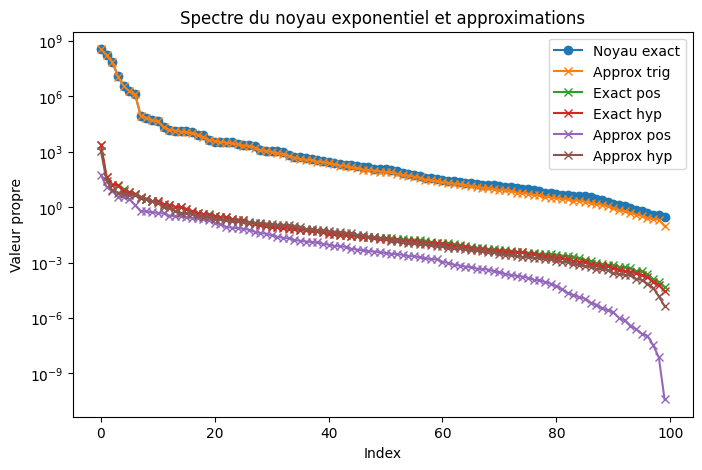

In [21]:
# Plot du spectre des matrices de Gram en comparant à l'approche exacte
plt.figure(figsize=(8, 5))
plt.plot(K_exp, label='Noyau exact', marker='o')   
plt.plot(K_trig, label='Approx trig', marker='x')
plt.plot(K_pos_exact, label='Exact pos', marker='x')
plt.plot(K_hyp_exact, label='Exact hyp', marker='x')
plt.plot(K_pos, label='Approx pos', marker='x')
plt.plot(K_hyp, label='Approx hyp', marker='x')
plt.yscale('log')
plt.title('Spectre du noyau exponentiel et approximations')
plt.xlabel('Index')
plt.ylabel('Valeur propre')
plt.legend()

La matrice de Gram n'est pas définie pour la loi normale centrée réduite. Nous essayons alors de réaliser les calculs en utilisant la loi normale centrée de variance 1/3.

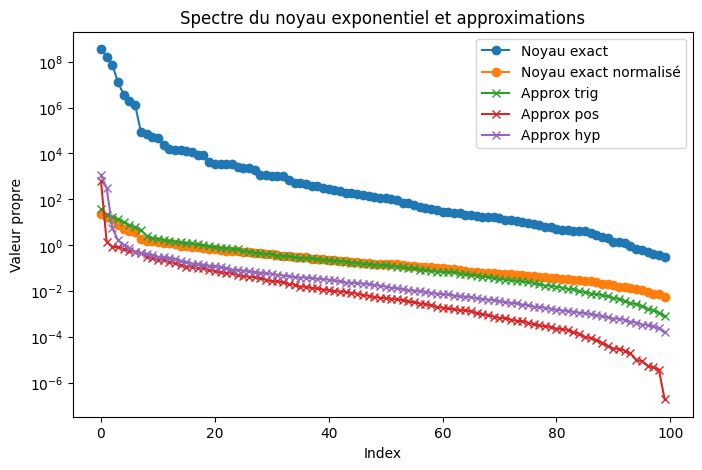

In [22]:
# les points x_i suivent un loi normale de variance 1/3 et moyenne nulle
X = np.random.randn(n, d) / np.sqrt(3)
omegas = np.random.randn(D, d) # Vecteurs aléatoires pour les feature maps

# Spectres approchés
K_trig = kernel_spectrum(X, sm_trig, omegas)
K_pos = kernel_spectrum(X, sm_pos, omegas)
K_hyp = kernel_spectrum(X, sm_hyp, omegas)

# Plot du spectre des approximations et du noyau exact sans normalisation et avec normalisation
plt.figure(figsize=(8, 5))
plt.plot(K_exp, label='Noyau exact', marker='o')
plt.plot(K_exp_norm, label='Noyau exact normalisé', marker='o')
plt.plot(K_trig, label='Approx trig', marker='x')
plt.plot(K_pos, label='Approx pos', marker='x')
plt.plot(K_hyp, label='Approx hyp', marker='x')
plt.yscale('log')
plt.title('Spectre du noyau exponentiel et approximations')
plt.xlabel('Index')
plt.ylabel('Valeur propre')
plt.legend()
plt.show()

Matrices de Gram :

Features map trigonometriques:


$$\phi^{\text{trig}}(x) = \frac{e^{\|x\|^2/2}}{\sqrt{D}} 
\begin{bmatrix} \cos(\omega_1^\top x) \\ \sin(\omega_1^\top x) \\ \vdots \\ 
\cos(\omega_D^\top x) \\ \sin(\omega_D^\top x) \end{bmatrix} \in \mathbb{R}^{2D}$$

$$G_{ij} = \frac{1}{D} \int_{\mathbb{R}^d}\frac{e^{-\frac{3\|x\|^2}{2}}}{\left(2\pi\frac{1}{3}\right)^{d/2}} e^{\|x\|^2}
( \cos{\omega_i^\top x}\cos{\omega_j^\top x} + \cos{\omega_i^\top x}\sin{\omega_j^\top x}
+ \sin{\omega_i^\top x}\cos{\omega_j^\top x} + \sin{\omega_i^\top x}\sin{\omega_j^\top x} ) dx $$

$$
= \frac{1}{D} \int_{\mathbb{R}^d} \frac{e^{-\frac{3\|x\|^2}{2}}}{\left(2\pi\frac{1}{3}\right)^{d/2}} e^{\|x\|^2} \left(\cos((\omega_i - \omega_j)^\top x) + \sin((\omega_i + \omega_j)^\top x)\right) dx$$

$$= \frac{1}{D} \cdot \frac{1}{\left(2\pi\frac{1}{3}\right)^{d/2}} \int_{\mathbb{R}^d} e^{-\frac{\|x\|^2}{2}} \left(\cos((\omega_i - \omega_j)^\top x) + \sin((\omega_i + \omega_j)^\top x)\right) dx$$

$$= \frac{1}{D\left(\frac{1}{3}\right)^{d/2}} \operatorname{Re}\!\left(\int_{\mathbb{R}^d} \frac{e^{-\frac{\|x\|^2}{2}}}{(2\pi)^{d/2}} e^{i(\omega_i - \omega_j)^\top x} dx\right)$$

$$= \frac{3^{d/2}}{D} \,\hat{\psi}_{\mathcal{N}(0,1)}(\omega_i - \omega_j) = \frac{3^{d/2}}{D} \, e^{-\frac{1}{2}\|\omega_i - \omega_j\|^2}$$


Feature map positif 

 $\phi^+_i(x) = \frac{e^{-\|x\|^2 /2}}{\sqrt{D}} e^{\omega_i^\top x}$, donc :

$$G_{ij} = \frac{1}{D} \int_{\mathbb{R}^d} e^{-\|x\|^2} e^{(\omega_i + \omega_j)^\top x} \cdot \frac{e^{-\frac{3\|x\|^2}{2}}}{\left(2\pi\frac{1}{3}\right)^{d/2}} \, dx 
= \frac{1}{D} \int_{\mathbb{R}^d} \frac{1}{\left(2\pi\frac{1}{3}\right)^{d/2}} e^{-\frac{5\|x\|^2}{2} + (\omega_i+\omega_j)^\top x} \, dx$$

Or :

$$-\frac{5}{2}\|x\|^2 + (\omega_i+\omega_j)^\top x 
= -\frac{5}{2}\left\|x - \frac{\omega_i+\omega_j}{5}\right\|^2 + \frac{\|\omega_i+\omega_j\|^2}{10}$$

En intégrant la gaussienne $\mathcal{N}\!\left(\frac{\omega_i+\omega_j}{5},\, \frac{1}{5}I_d\right)$, on obtient :

$${G_{ij} = \frac{1}{D} (\frac{3}{5})^{d/2}\exp\!\left(\frac{\|\omega_i + \omega_j\|^2}{10}\right)}$$


Feature map hyperbolique :

 $\phi^{\text{hyp}}_i(x) = \frac{e^{-\|x\|^2/2}}{\sqrt{2D}} [e^{\omega_i^\top x},\, e^{-\omega_i^\top x}]^\top$. 

Alors, 
$$G_{ij} = \frac{1}{2D} \int_{\mathbb{R}^d} \frac{e^{-\|x\|^2}}{\left(2\pi\frac{1}{3}\right)^{d/2}} e^{-3\|x\|^2/2}
\left( e^{(\omega_i+\omega_j)^\top x} + e^{-(\omega_i+\omega_j)^\top x} 
+ e^{(\omega_i-\omega_j)^\top x} + e^{(-\omega_i+\omega_j)^\top x}\right) dx$$

$$= \frac{1}{2D} \int_{\mathbb{R}^d} \frac{1}{\left(2\pi\frac{1}{3}\right)^{d/2}} e^{-\frac{5}{2}\|x\|^2}
\left( e^{(\omega_i+\omega_j)^\top x} + e^{-(\omega_i+\omega_j)^\top x} 
+ e^{(\omega_i-\omega_j)^\top x} + e^{(-\omega_i+\omega_j)^\top x}\right) dx$$

Chaque terme est une intégrale gaussienne. En complétant le carré 
$-\frac{5}{2}\|x\|^2 + v^\top x = -\frac{5}{2}\|x - \frac{v}{5}\|^2 + \frac{\|v\|^2}{10}$, on obtient :

$$G_{ij}^{++} = G_{ij}^{--} = \frac{1}{2D} (\frac{3}{5})^{d/2} \exp\!\left(\frac{\|\omega_i+\omega_j\|^2}{10}\right)$$

$$G_{ij}^{+-} = G_{ij}^{-+} =\frac{1}{2D} (\frac{3}{5})^{d/2}\exp\!\left(\frac{\|\omega_i-\omega_j\|^2}{10}\right)$$

En sommant les quatre blocs :

$${G_{ij} = \frac{1}{D} (\frac{3}{5})^{d/2}\left[\exp\!\left(\frac{\|\omega_i+\omega_j\|^2}{10}\right) 
+ \exp\!\left(\frac{\|\omega_i-\omega_j\|^2}{10}\right)\right]}$$

In [9]:
def gram_exact_trig(omegas, d):
    D = omegas.shape[0]
    dot          = omegas @ omegas.T
    norms_sq     = np.sum(omegas**2, axis=1)
    sum_norms_sq = norms_sq[:, None] + norms_sq[None, :]
    norm_diff_sq = sum_norms_sq - 2*dot

    G = (3**(d/2) / D) * np.exp(-norm_diff_sq / 2)
    return G

def gram_exact_pos_v2(omegas, d):
    D = omegas.shape[0]
    dot          = omegas @ omegas.T
    norms_sq     = np.sum(omegas**2, axis=1)
    sum_norms_sq = norms_sq[:, None] + norms_sq[None, :]
    norm_sum_sq  = sum_norms_sq + 2*dot

    G = ((3/5)**(d/2) / D) * np.exp(norm_sum_sq / 10)
    return G

def gram_exact_hyp_v2(omegas, d):
    D = omegas.shape[0]
    dot          = omegas @ omegas.T
    norms_sq     = np.sum(omegas**2, axis=1)
    sum_norms_sq = norms_sq[:, None] + norms_sq[None, :]
    norm_sum_sq  = sum_norms_sq + 2*dot
    norm_diff_sq = sum_norms_sq - 2*dot

    G = ((3/5)**(d/2) / D) * (np.exp(norm_sum_sq / 10) + np.exp(norm_diff_sq / 10))
    return G

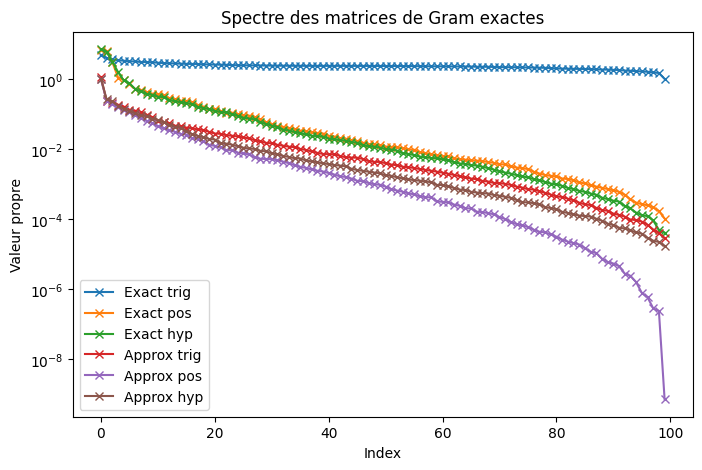

In [12]:
# Calcul des matrices de Gram exactes pour D=100 et d=10
D = 100
d = 10

omegas = np.random.randn(D, d)
X = np.random.randn(D, d)*(1/3) # 100 points dans R^10 : mu est une gaussienne standard

G_trig = gram_exact_trig(omegas, d)
G_pos  = gram_exact_pos_v2(omegas, d)
G_hyp  = gram_exact_hyp_v2(omegas, d)

# Valeurs propres des matrices de Gram
eig_trig = np.linalg.eigvalsh(G_trig)[::-1]
eig_pos  = np.linalg.eigvalsh(G_pos)[::-1]
eig_hyp  = np.linalg.eigvalsh(G_hyp)[::-1]

K_trig = kernel_spectrum(X, sm_trig, omegas)
K_pos = kernel_spectrum(X, sm_pos, omegas)
K_hyp = kernel_spectrum(X, sm_hyp, omegas)

# Plot du spectre des matrices de Gram exactes et comparaison avec les approches approximatives
plt.figure(figsize=(8, 5))
plt.plot(eig_trig, label='Exact trig', marker='x')
plt.plot(eig_pos, label='Exact pos', marker='x')
plt.plot(eig_hyp, label='Exact hyp', marker='x')
plt.plot(K_trig, label='Approx trig', marker='x')
plt.plot(K_pos, label='Approx pos', marker='x')
plt.plot(K_hyp, label='Approx hyp', marker='x')
plt.yscale('log')
plt.title('Spectre des matrices de Gram exactes')
plt.xlabel('Index')
plt.ylabel('Valeur propre')
plt.legend()
plt.show()


Erreur entre produit scalaire